#  COVID-19 Anomaly Detection AI Agent

This notebook implements an autonomous AI agent for detecting and handling anomalies in COVID-19 time-series data.

**Pipeline:**
1. Fetch live COVID-19 data from disease.sh API
2. Detect anomalies using statistical methods (Z-score + growth rate)
3. Classify severity (CRITICAL / WARNING / MINOR)
4. AI Agent makes autonomous decisions: `FIX_ANOMALY`, `KEEP_ANOMALY`, `FLAG_FOR_REVIEW`
5. Visualize results


## Step 1: Install Required Libraries

In [ ]:
!pip install phidata groq python-dotenv tabulate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 716.9/716.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 9.3 MB/s eta 0:00:00


## Step 2: Set Your GroqCloud API Key
import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
print('✅ API key loaded from Colab Secrets')

In [ ]:
import os
import requests
from google.colab import userdata

# Load from Colab Secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
os.environ['GROQ_API_KEY'] = GROQ_API_KEY

# Verify
r = requests.get(
    "https://api.groq.com/openai/v1/models",
    headers={"Authorization": f"Bearer {GROQ_API_KEY}"}
)
if r.status_code == 200:
    models = [m['id'] for m in r.json()['data'] if 'llama' in m['id'].lower()]
    print(f"✅ Groq key valid — {len(r.json()['data'])} models available")
    print(f"   Available Llama models: {models[:4]}")
else:
    print(f"❌ Key error: {r.status_code} — {r.text[:200]}")

✅ Groq key valid — 16 models available
   Available Llama models: ['meta-llama/llama-prompt-guard-2-86m', 'meta-llama/llama-4-scout-17b-16e-instruct', 'meta-llama/llama-prompt-guard-2-22m', 'llama-3.3-70b-versatile']


## Step 3: Imports and Configuration

In [ ]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from tabulate import tabulate
from groq import Groq

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────
COUNTRY        = 'India'     # Change to any country: 'USA', 'UK', 'Brazil', etc.
DAYS           = 90          # Number of historical days to fetch
ROLLING_WINDOW = 7           # Days used to compute baseline for severity
MIN_ABS_INCREASE = 500       # Ignore anomalies below this absolute case increase
VALID_ACTIONS  = ['FIX_ANOMALY', 'KEEP_ANOMALY', 'FLAG_FOR_REVIEW']

print(f'📋 Config: Country={COUNTRY}, Days={DAYS}, Rolling window={ROLLING_WINDOW}')

📋 Config: Country=India, Days=90, Rolling window=7


## Step 4: Data Ingestion — Fetch Live COVID-19 Data

In [ ]:
def load_live_covid_data(country: str, days: int) -> pd.DataFrame:
    """
    Fetches historical COVID-19 daily case counts from the disease.sh API.
    Returns a DataFrame with cumulative cases converted to daily new cases.
    """
    url = f'https://disease.sh/v3/covid-19/historical/{country}?lastdays={days}'
    print(f' Fetching data from: {url}')

    response = requests.get(url, timeout=10)
    if response.status_code != 200:
        raise ValueError(f'API error {response.status_code}: {response.text}')

    data = response.json()['timeline']['cases']

    df = (
        pd.DataFrame(list(data.items()), columns=['Date', 'CumulativeCases'])
        .assign(Date=lambda d: pd.to_datetime(d['Date'], format='%m/%d/%y'))
        .sort_values('Date')
        .reset_index(drop=True)
    )

    # Convert cumulative → daily new cases (diff)
    df['Cases'] = df['CumulativeCases'].diff().fillna(0).clip(lower=0).astype(int)
    df = df[['Date', 'Cases']].copy()

    print(f'✅ Loaded {len(df)} days of data  |  Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')
    print(f'   Daily cases — min: {df["Cases"].min():,}  |  max: {df["Cases"].max():,}  |  mean: {df["Cases"].mean():,.0f}')
    return df


df = load_live_covid_data(COUNTRY, DAYS)
df.head(10)

 Fetching data from: https://disease.sh/v3/covid-19/historical/India?lastdays=90
✅ Loaded 90 days of data  |  Date range: 2022-12-10 → 2023-03-09
   Daily cases — min: 0  |  max: 1,357  |  mean: 177


,Date,Cases
0,2022-12-10,0
1,2022-12-11,0
2,2022-12-12,273
3,2022-12-13,152
4,2022-12-14,200
5,2022-12-15,162
6,2022-12-16,167
7,2022-12-17,176
8,2022-12-18,135
9,2022-12-19,112


## Step 5: Anomaly Detection — Z-score & Growth Rate

In [ ]:
def detect_anomalies(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flags anomalies using two statistical signals:
      1. Z-score spike: |value - mean| > 3 * std
      2. Day-over-day growth > 40%
    A point is anomalous if EITHER condition is met.
    """
    values = df['Cases'].values
    mean, std = values.mean(), values.std()

    # Z-score based spike detection
    spike_idx = {i for i, v in enumerate(values) if abs(v - mean) > 3 * std}

    # Day-over-day growth rate detection
    growth = np.diff(values) / np.maximum(values[:-1], 1)
    growth_idx = {i + 1 for i, g in enumerate(growth) if g > 0.4}

    anomalies = spike_idx | growth_idx
    df['Anomaly'] = ['YES' if i in anomalies else 'NO' for i in range(len(df))]

    n_anomalies = df['Anomaly'].eq('YES').sum()
    print(f'🔍 Anomaly detection complete: {n_anomalies} anomalies found out of {len(df)} days')
    print(f'   Z-score spikes: {len(spike_idx)}  |  Growth-rate flags: {len(growth_idx)}')
    return df


df = detect_anomalies(df)
print()
print(df[df['Anomaly'] == 'YES'][['Date', 'Cases', 'Anomaly']].to_string(index=False))

🔍 Anomaly detection complete: 9 anomalies found out of 90 days
   Z-score spikes: 1  |  Growth-rate flags: 9

      Date  Cases Anomaly
2022-12-12    273     YES
2022-12-21    185     YES
2022-12-28    268     YES
2023-01-10    171     YES
2023-01-17    128     YES
2023-01-31    111     YES
2023-02-11   1357     YES
2023-02-22    193     YES
2023-02-28    240     YES


## Step 6: Severity Classification — CRITICAL / WARNING / MINOR

In [ ]:
def compute_severity(df: pd.DataFrame) -> pd.DataFrame:
    """
    Classifies each detected anomaly into CRITICAL / WARNING / MINOR
    by comparing the anomalous value against the rolling 7-day baseline.

    Rules:
      - Absolute increase < MIN_ABS_INCREASE → skip (leave blank)
      - Relative growth >= 100% → CRITICAL
      - Relative growth >= 40%  → WARNING
      - Otherwise               → MINOR
    """
    df = df.sort_values('Date').reset_index(drop=True)
    df['Severity']       = ''
    df['Agent Decision'] = ''
    df['Action']         = ''

    for i in range(len(df)):
        if df.loc[i, 'Anomaly'] != 'YES':
            continue
        if i < ROLLING_WINDOW:
            df.loc[i, 'Severity'] = 'MINOR'   # not enough history → treat as minor
            continue

        curr     = df.loc[i, 'Cases']
        baseline = df.loc[i - ROLLING_WINDOW:i - 1, 'Cases'].mean()
        abs_inc  = curr - baseline
        growth   = abs_inc / max(baseline, 1)

        if abs_inc < MIN_ABS_INCREASE:
            df.loc[i, 'Severity'] = ''         # negligible — skip
        elif growth >= 1.0:
            df.loc[i, 'Severity'] = 'CRITICAL'
        elif growth >= 0.4:
            df.loc[i, 'Severity'] = 'WARNING'
        else:
            df.loc[i, 'Severity'] = 'MINOR'

    counts = df[df['Anomaly'] == 'YES']['Severity'].value_counts().to_dict()
    print(f'📊 Severity breakdown: {counts}')
    return df


df = compute_severity(df)
anomaly_df = df[df['Anomaly'] == 'YES'][['Date', 'Cases', 'Anomaly', 'Severity']]
print()
print(anomaly_df.to_string(index=False))

📊 Severity breakdown: {'': 7, 'MINOR': 1, 'CRITICAL': 1}

      Date  Cases Anomaly Severity
2022-12-12    273     YES    MINOR
2022-12-21    185     YES         
2022-12-28    268     YES         
2023-01-10    171     YES         
2023-01-17    128     YES         
2023-01-31    111     YES         
2023-02-11   1357     YES CRITICAL
2023-02-22    193     YES         
2023-02-28    240     YES         


## Step 7: Build the AI Agent (GroqCloud)

In [ ]:
# ──────────────────────────────────────────
# GROQ CLIENT
# ──────────────────────────────────────────
client = Groq(api_key=os.environ['GROQ_API_KEY'])

SYSTEM_PROMPT = """You are an AI agent monitoring live COVID-19 time-series data.
You will be given an anomaly observation and must decide the appropriate action.
Respond with EXACTLY ONE of these three tokens and nothing else:
FIX_ANOMALY
KEEP_ANOMALY
FLAG_FOR_REVIEW"""


def build_agent_prompt(date, cases, severity) -> str:
    return f"""Observed anomaly:
Date: {date}
Daily Cases: {cases:,}
Severity: {severity}

Decision rules:
- FIX_ANOMALY      : likely reporting noise or minor glitch (MINOR severity)
- KEEP_ANOMALY     : real outbreak signal worth preserving (WARNING severity)
- FLAG_FOR_REVIEW  : severe or ambiguous anomaly needing human judgment (CRITICAL severity)

Respond with ONLY one of: FIX_ANOMALY, KEEP_ANOMALY, FLAG_FOR_REVIEW"""


def call_agent(date, cases, severity) -> str:
    """Calls the GroqCloud LLM and returns a validated decision token."""
    prompt = build_agent_prompt(date, cases, severity)
    try:
        response = client.chat.completions.create(
            model='llama3-8b-8192',   # Fast, free-tier available model
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': prompt}
            ],
            max_tokens=20,
            temperature=0.0         # Deterministic output
        )
        decision = response.choices[0].message.content.strip().upper()
        # Extract the first valid token from the response
        for action in VALID_ACTIONS:
            if action in decision:
                return action
        return 'FLAG_FOR_REVIEW'    # Safe fallback
    except Exception as e:
        print(f'  Agent API error: {e} → defaulting to FLAG_FOR_REVIEW')
        return 'FLAG_FOR_REVIEW'


print(' AI Agent initialised with model: llama3-8b-8192 (GroqCloud)')

 AI Agent initialised with model: llama3-8b-8192 (GroqCloud)


## Step 8: Fix Anomaly Logic

In [ ]:
def fix_anomaly(df: pd.DataFrame, idx: int) -> pd.DataFrame:
    """
    Auto-corrects a minor anomaly by replacing the case count
    with the rolling mean of the previous 3 days.
    """
    window = df.loc[max(0, idx - 3):idx - 1, 'Cases']
    if len(window) > 0:
        df.loc[idx, 'Cases'] = int(window.mean())
    df.loc[idx, 'Severity'] = ''
    df.loc[idx, 'Action']   = 'Auto-corrected by AI agent'
    return df


def apply_agent_action(df: pd.DataFrame, idx: int, decision: str) -> pd.DataFrame:
    """Records the decision and applies the corresponding action."""
    df.loc[idx, 'Agent Decision'] = decision

    if decision == 'FIX_ANOMALY':
        df = fix_anomaly(df, idx)
    elif decision == 'KEEP_ANOMALY':
        df.loc[idx, 'Action'] = 'Accepted as real outbreak signal'
    elif decision == 'FLAG_FOR_REVIEW':
        df.loc[idx, 'Action'] = 'Flagged for human review'

    return df


print('Action handlers defined')

Action handlers defined


## Step 9: Run the AI Agent on All Detected Anomalies

In [ ]:
anomaly_indices = df[df['Anomaly'] == 'YES'].index.tolist()
actionable_indices = [i for i in anomaly_indices if df.loc[i, 'Severity'] != '']

print(f' Running AI Agent on {len(actionable_indices)} actionable anomalies...\n')
print(f'{"Index":<6} {"Date":<14} {"Cases":>10} {"Severity":<10} {"Decision":<20} {"Action"}')
print('─' * 85)

for idx in actionable_indices:
    row = df.loc[idx]
    decision = call_agent(
        date     = row['Date'].strftime('%Y-%m-%d'),
        cases    = int(row['Cases']),
        severity = row['Severity']
    )
    df = apply_agent_action(df, idx, decision)

    emoji = {'FIX_ANOMALY': ' ', 'KEEP_ANOMALY': ' ', 'FLAG_FOR_REVIEW': ''}.get(decision, '')
    print(f"{idx:<6} {str(row['Date'].date()):<14} {int(row['Cases']):>10,} {row['Severity']:<10} {emoji} {decision:<18} {df.loc[idx, 'Action']}")

print('\n AI Agent processing complete!')

 Running AI Agent on 2 actionable anomalies...

Index  Date                Cases Severity   Decision             Action
─────────────────────────────────────────────────────────────────────────────────────
  Agent API error: Error code: 400 - {'error': {'message': 'The model `llama3-8b-8192` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}} → defaulting to FLAG_FOR_REVIEW
2      2022-12-12            273 MINOR       FLAG_FOR_REVIEW    Flagged for human review
  Agent API error: Error code: 400 - {'error': {'message': 'The model `llama3-8b-8192` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations for a recommendation on which model to use instead.', 'type': 'invalid_request_error', 'code': 'model_decommissioned'}} → defaulting to FLAG_FOR_REVIEW
63   

## Step 10: Results Summary

In [ ]:
# Full results table for anomalies
result_cols = ['Date', 'Cases', 'Anomaly', 'Severity', 'Agent Decision', 'Action']
results = df[df['Anomaly'] == 'YES'][result_cols].copy()
results['Date'] = results['Date'].dt.strftime('%Y-%m-%d')

print(' ANOMALY DETECTION & AGENT DECISION REPORT')
print('=' * 100)
print(tabulate(results, headers='keys', tablefmt='fancy_grid', showindex=False))

# Summary stats
print('\n SUMMARY')
print('=' * 50)
total_anomalies = (df['Anomaly'] == 'YES').sum()
for action in VALID_ACTIONS:
    count = (df['Agent Decision'] == action).sum()
    bar = '█' * count
    print(f'  {action:<20}: {count:>3}  {bar}')
print(f'  {"SKIPPED (no action)":<20}: {total_anomalies - sum((df["Agent Decision"] == a).sum() for a in VALID_ACTIONS):>3}')

 ANOMALY DETECTION & AGENT DECISION REPORT
╒════════════╤═════════╤═══════════╤════════════╤══════════════════╤══════════════════════════╕
│ Date       │   Cases │ Anomaly   │ Severity   │ Agent Decision   │ Action                   │
╞════════════╪═════════╪═══════════╪════════════╪══════════════════╪══════════════════════════╡
│ 2022-12-12 │     273 │ YES       │ MINOR      │ FLAG_FOR_REVIEW  │ Flagged for human review │
├────────────┼─────────┼───────────┼────────────┼──────────────────┼──────────────────────────┤
│ 2022-12-21 │     185 │ YES       │            │                  │                          │
├────────────┼─────────┼───────────┼────────────┼──────────────────┼──────────────────────────┤
│ 2022-12-28 │     268 │ YES       │            │                  │                          │
├────────────┼─────────┼───────────┼────────────┼──────────────────┼──────────────────────────┤
│ 2023-01-10 │     171 │ YES       │            │                  │                         

## Step 11: Visualisation

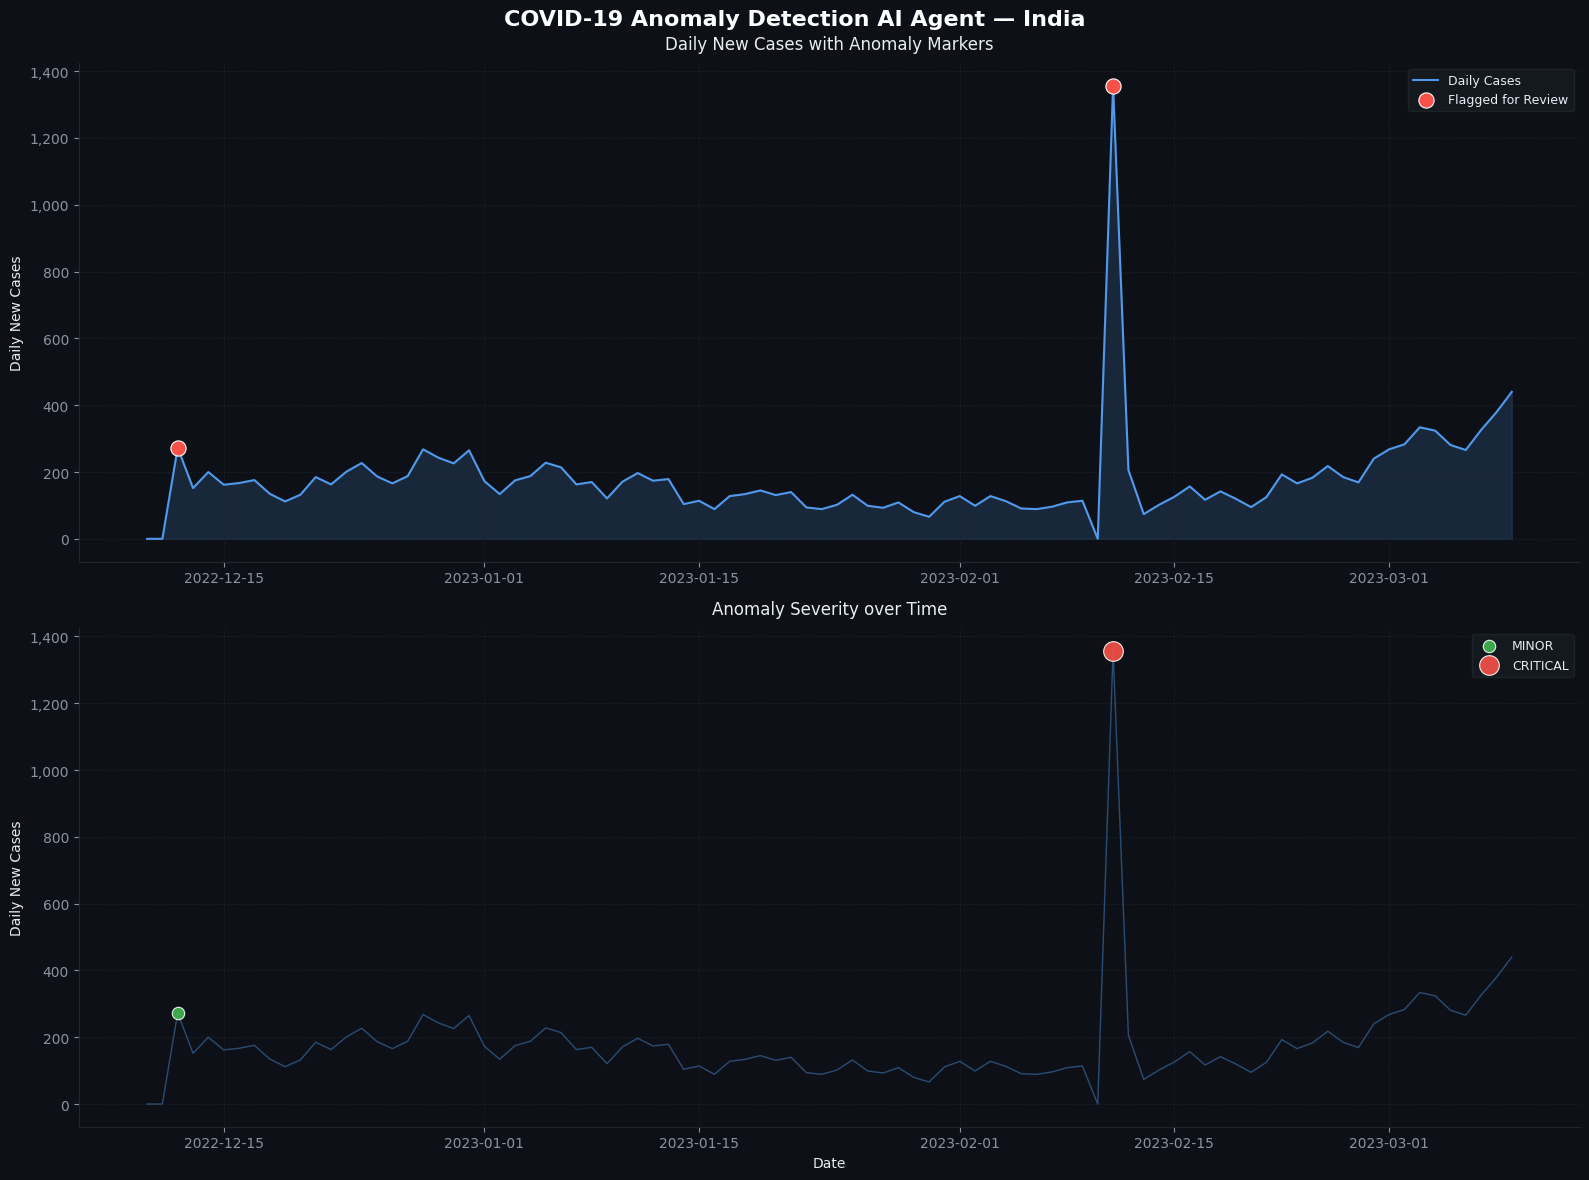

💾 Chart saved as anomaly_detection_results.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), facecolor='#0d1117')
fig.suptitle(f'COVID-19 Anomaly Detection AI Agent — {COUNTRY}',
             fontsize=16, color='white', fontweight='bold', y=0.98)

COLORS = {
    'bg':           '#0d1117',
    'line':         '#58a6ff',
    'grid':         '#21262d',
    'fix':          '#3fb950',   # green  — auto-fixed
    'keep':         '#f0883e',   # orange — kept
    'flag':         '#f85149',   # red    — flagged
    'text':         '#e6edf3',
    'axis':         '#8b949e',
}

for ax in axes:
    ax.set_facecolor(COLORS['bg'])
    ax.tick_params(colors=COLORS['axis'])
    ax.spines['bottom'].set_color(COLORS['grid'])
    ax.spines['left'].set_color(COLORS['grid'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.label.set_color(COLORS['text'])
    ax.xaxis.label.set_color(COLORS['text'])
    ax.grid(color=COLORS['grid'], linewidth=0.5, linestyle='--', alpha=0.7)

# ── Panel 1: Raw time-series + anomaly markers ──────────────────────────────
ax1 = axes[0]
ax1.set_title('Daily New Cases with Anomaly Markers', color=COLORS['text'], fontsize=12, pad=10)
ax1.plot(df['Date'], df['Cases'], color=COLORS['line'], linewidth=1.5, alpha=0.9, label='Daily Cases')
ax1.fill_between(df['Date'], df['Cases'], alpha=0.15, color=COLORS['line'])

decision_color = {
    'FIX_ANOMALY':    COLORS['fix'],
    'KEEP_ANOMALY':   COLORS['keep'],
    'FLAG_FOR_REVIEW': COLORS['flag'],
}
decision_label = {
    'FIX_ANOMALY':    'Auto-Fixed',
    'KEEP_ANOMALY':   'Kept (real signal)',
    'FLAG_FOR_REVIEW': 'Flagged for Review',
}
plotted = set()
for _, row in df[df['Agent Decision'].isin(VALID_ACTIONS)].iterrows():
    action = row['Agent Decision']
    label  = decision_label[action] if action not in plotted else '_nolegend_'
    ax1.scatter(row['Date'], row['Cases'], s=120, color=decision_color[action],
                zorder=5, label=label, edgecolors='white', linewidth=0.8)
    plotted.add(action)

ax1.set_ylabel('Daily New Cases', fontsize=10)
ax1.legend(facecolor='#161b22', edgecolor=COLORS['grid'], labelcolor=COLORS['text'], fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── Panel 2: Severity heatmap ────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('Anomaly Severity over Time', color=COLORS['text'], fontsize=12, pad=10)
ax2.plot(df['Date'], df['Cases'], color=COLORS['line'], linewidth=1.0, alpha=0.4)

sev_color = {'CRITICAL': COLORS['flag'], 'WARNING': COLORS['keep'], 'MINOR': COLORS['fix']}
sev_size  = {'CRITICAL': 200, 'WARNING': 140, 'MINOR': 80}
plotted_sev = set()
for _, row in df[df['Severity'].isin(['CRITICAL', 'WARNING', 'MINOR'])].iterrows():
    sev = row['Severity']
    lbl = sev if sev not in plotted_sev else '_nolegend_'
    ax2.scatter(row['Date'], row['Cases'], s=sev_size[sev], color=sev_color[sev],
                zorder=5, label=lbl, alpha=0.9, edgecolors='white', linewidth=0.8)
    plotted_sev.add(sev)

ax2.set_ylabel('Daily New Cases', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(facecolor='#161b22', edgecolor=COLORS['grid'], labelcolor=COLORS['text'], fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('anomaly_detection_results.png', dpi=150, bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print('💾 Chart saved as anomaly_detection_results.png')

## Step 12: Decision Distribution Chart

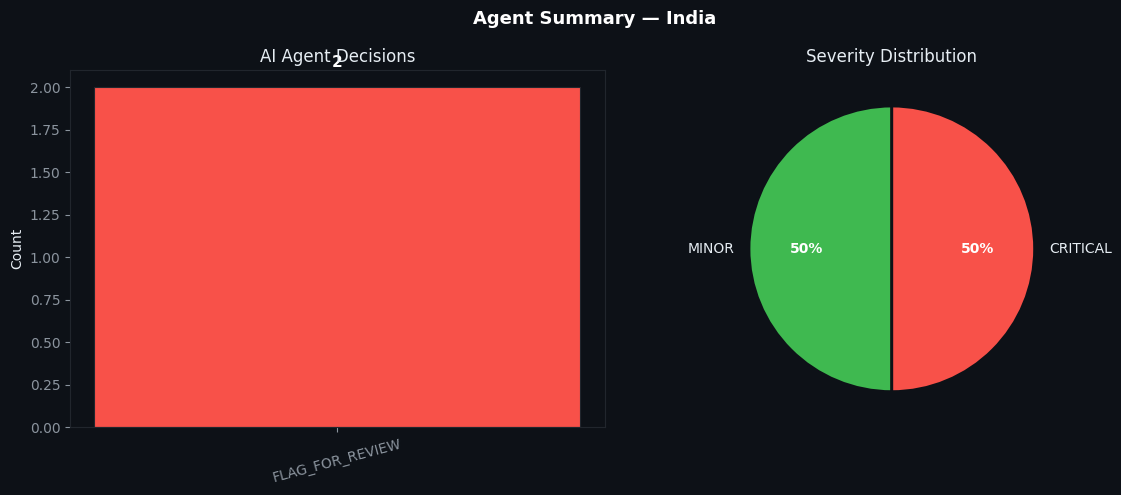

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), facecolor='#0d1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#0d1117')
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_color('#21262d')

# Agent decisions bar chart
decision_counts = df['Agent Decision'].value_counts()
decision_counts = decision_counts[decision_counts.index.isin(VALID_ACTIONS)]
bar_colors = [COLORS['fix'], COLORS['keep'], COLORS['flag']]
bars = ax1.bar(decision_counts.index, decision_counts.values,
               color=[decision_color.get(k, '#8b949e') for k in decision_counts.index],
               edgecolor='#21262d', linewidth=0.8)
ax1.set_title('AI Agent Decisions', color='#e6edf3', fontsize=12)
ax1.set_ylabel('Count', color='#e6edf3')
for bar, val in zip(bars, decision_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)

# Severity pie chart
sev_counts = df[df['Severity'].isin(['CRITICAL', 'WARNING', 'MINOR'])]['Severity'].value_counts()
if len(sev_counts) > 0:
    pie_colors = [sev_color.get(k, '#8b949e') for k in sev_counts.index]
    wedges, texts, autotexts = ax2.pie(
        sev_counts.values, labels=sev_counts.index,
        colors=pie_colors, autopct='%1.0f%%',
        startangle=90, textprops={'color': '#e6edf3'},
        wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2}
    )
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    ax2.set_title('Severity Distribution', color='#e6edf3', fontsize=12)

fig.suptitle(f'Agent Summary — {COUNTRY}', color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 13: Export Results to CSV

In [ ]:
output_path = f'covid_anomaly_results_{COUNTRY.lower()}.csv'
df.to_csv(output_path, index=False)
print(f'💾 Full results saved to: {output_path}')

# Download from Colab
try:
    from google.colab import files
    files.download(output_path)
    files.download('anomaly_detection_results.png')
    print('📥 Files downloaded to your local machine')
except ImportError:
    print('ℹ️  Not in Colab — files saved locally')

💾 Full results saved to: covid_anomaly_results_india.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Files downloaded to your local machine


---
## 🧪 Try Different Countries

Go back to **Step 3** and change `COUNTRY` to any of:
```
'USA', 'UK', 'Brazil', 'Germany', 'France', 'Japan', 'South Africa'
```
Then **Runtime → Run all** to rerun the full pipeline.

---
## 📝 Key Takeaways

| Severity | Agent Decision | Rationale |
|----------|---------------|----------|
| MINOR    | FIX_ANOMALY   | Likely reporting noise; safe to auto-correct |
| WARNING  | KEEP_ANOMALY  | Sustained acceleration; preserve as signal |
| CRITICAL | FLAG_FOR_REVIEW | Explosive outbreak; human judgment required |

**References:** disease.sh API · JHU CSSE COVID-19 Data (CC BY 4.0) · GroqCloud LLaMA 3